In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

## **Load Dataset**

In [19]:
df = pd.read_csv("e_waste_cleaned_recoverable.csv")
df.head()

,Item,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon,Profit ($),Total_Value,Recoverable
0,iPhone 11,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51,270.34,1747.586811,1
1,Toaster,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22,689.75,1827.215202,1
2,Speaker,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83,570.43,1946.945103,1
3,Microwave Oven,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36,290.78,1595.124886,0
4,Air Conditioner,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53,505.16,1395.768663,0


In [21]:
X = df.drop(columns=["Item", "Category", "Recoverable", "Profit ($)", "Total_Value"])
y = df["Recoverable"]

## **Train Test Split**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## **Random Forest Classifier**

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
y_pred = rf_model.predict(X_test)

## **Accuracy**

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9785


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1296   11]
 [  32  661]]


## **Feature Importance**

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Rhodium     0.607896
Platinum    0.176379
Gold        0.123903
Aluminum    0.016295
Nickel      0.015620
Tin         0.015357
Carbon      0.015215
Lithium     0.014864
Silver      0.014470
dtype: float64


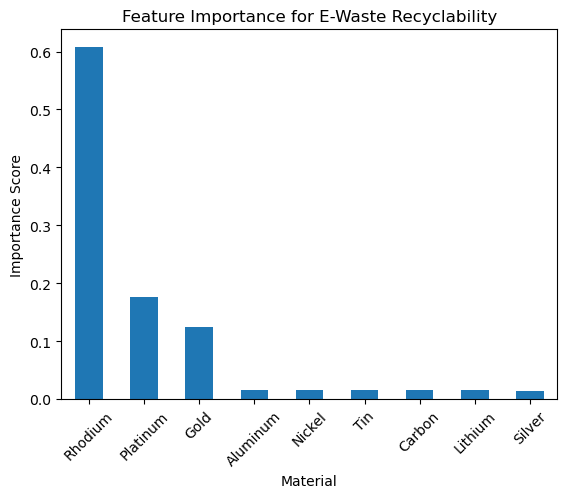

In [37]:
feature_importance.plot(kind="bar")

plt.title("Feature Importance for E-Waste Recyclability")
plt.xlabel("Material")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)
plt.show()

## Evaluation
In this section we evaluate the trained Random Forest model using Confusion Matrix and Classification Report to understand the model's performance beyond just accuracy.

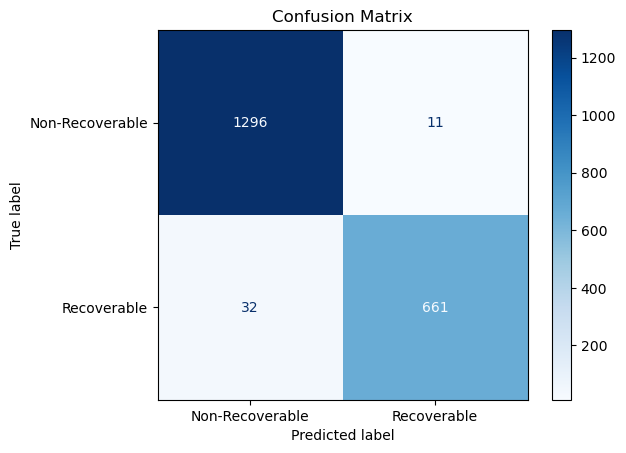

                 precision    recall  f1-score   support

Non-Recoverable       0.98      0.99      0.98      1307
    Recoverable       0.98      0.95      0.97       693

       accuracy                           0.98      2000
      macro avg       0.98      0.97      0.98      2000
   weighted avg       0.98      0.98      0.98      2000



In [43]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

# 1. Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Recoverable', 'Recoverable'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# 2. Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Non-Recoverable', 'Recoverable']))



## Fine Tuning
The training team used default parameters for Random Forest. Fine tuning optimizes the internal parameters of the model using GridSearchCV to find the best combination that gives the highest performance.

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Macro: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

print(f"\nTuned Model Accuracy: {accuracy_score(y_test, best_preds):.4f}")
print(classification_report(y_test, best_preds,
      target_names=['Non-Recoverable', 'Recoverable']))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-Macro: 0.9775

Tuned Model Accuracy: 0.9790
                 precision    recall  f1-score   support

Non-Recoverable       0.98      0.99      0.98      1307
    Recoverable       0.99      0.95      0.97       693

       accuracy                           0.98      2000
      macro avg       0.98      0.97      0.98      2000
   weighted avg       0.98      0.98      0.98      2000



### Final Predictions with Item Names
Adding the Item column back to the final predictions output for better readability and presentation. This helps us understand which specific electronic items are recoverable or non-recoverable.

In [55]:
# Add Item back to test results
results = X_test.copy()
results['Item'] = df.loc[X_test.index, 'Item']
results['Actual'] = y_test.values
results['Predicted'] = best_preds

# Show sample predictions
print(results[['Item', 'Actual', 'Predicted']].head(10))

# Save to CSV
results[['Item', 'Actual', 'Predicted']].to_csv('ewaste_predictions.csv', index=False)
print("Predictions saved!")

         Item  Actual  Predicted
6252       TV       0          0
4684     Iron       0          0
1731       TV       0          0
4742     Iron       0          0
4521  Speaker       1          1
6340  Monitor       0          0
576    Laptop       0          0
5202   Laptop       0          0
6363       TV       0          0
439    Tablet       0          0
Predictions saved!
